First we will load the python packages and datasets that we need

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from ml_from_scratch.supervised.random_forest import RandomForest

We will now load our data and split it into testing and training data in order to test our model

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

We will now train a random forest with 10 trees on this data and evaluate its accuracy

In [4]:
forest = RandomForest(n_trees=10, max_depth=5, min_samples_split=2, random_state=0)
forest.train(X_train, y_train)
forest_preds = forest.predict(X_test)
forest_acc = np.mean(forest_preds == y_test)
print(f"Random Forest accuracy: {forest_acc:.4f}")

Random Forest accuracy: 0.9474


Note that while this is slightly better than the decision tree, it took 5x as long. This is because we had to train a bunch of trees which already take a while to train. The increase in accuracy on the same dataset shows that there is good reason to utilize this algorithm rather than the normal decision tree. To illustrate differences in accuracy between numbers of trees, I will iterate through a couple sizes of forests and compare their accuracy

1 trees: accuracy = 0.9035
2 trees: accuracy = 0.9035
5 trees: accuracy = 0.9474
10 trees: accuracy = 0.9474
20 trees: accuracy = 0.9474
50 trees: accuracy = 0.9561


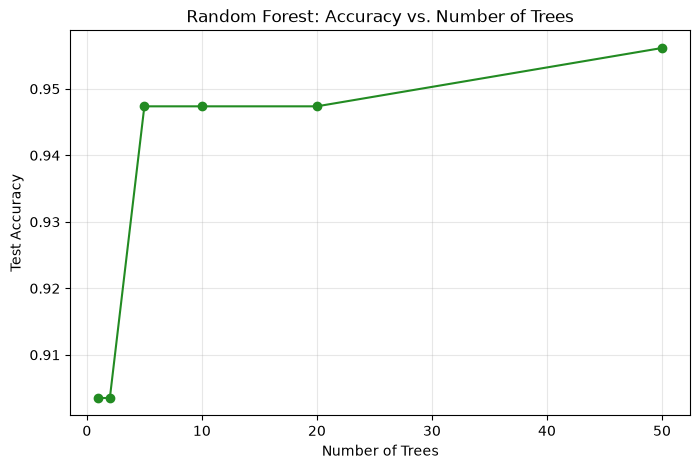

In [5]:
tree_counts = [1, 2, 5, 10, 20, 50]
accuracies = []

for n in tree_counts:
    f = RandomForest(n_trees=n, max_depth=5, min_samples_split=2, random_state=0)
    f.train(X_train, y_train)
    acc = np.mean(f.predict(X_test) == y_test)
    accuracies.append(acc)
    print(f"{n} trees: accuracy = {acc:.4f}")   # progress as it runs

plt.figure(figsize=(8, 5))
plt.plot(tree_counts, accuracies, marker='o', color='forestgreen')
plt.xlabel('Number of Trees')
plt.ylabel('Test Accuracy')
plt.title('Random Forest: Accuracy vs. Number of Trees')
plt.grid(True, alpha=0.3)
plt.show()

As you can see, an increase in trees does not necessarily cause a huge increase to accuracy, however these small increases in accuracy become very important when training models like these. 